<a href="https://colab.research.google.com/github/arsalanmontazeri/Arsalan-Montazeri/blob/main/unlimited_car.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# For displaying all of the columns in dataframes
pd.set_option('display.max_column',None)
# For data modeling
from xgboost import XGBClassifier
from xgboost import plot_importance
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
# For saving models
import pickle
import plotly.express as px
import geopandas as gpd

In [ ]:
data = pd.read_csv('The Ultimate Cars Dataset 2024.csv', encoding='latin-1')


In [ ]:
data.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [ ]:
data.shape

(1213, 11)

In [ ]:
data.isna().sum()

,0
Company Names,0
Cars Names,0
Engines,0
CC/Battery Capacity,3
HorsePower,0
Total Speed,0
Performance(0 - 100 )KM/H,6
Cars Prices,0
Fuel Types,0
Seats,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1213 non-null   object
 1   Cars Names                 1213 non-null   object
 2   Engines                    1213 non-null   object
 3   CC/Battery Capacity        1210 non-null   object
 4   HorsePower                 1213 non-null   object
 5   Total Speed                1213 non-null   object
 6   Performance(0 - 100 )KM/H  1207 non-null   object
 7   Cars Prices                1213 non-null   object
 8   Fuel Types                 1213 non-null   object
 9   Seats                      1213 non-null   object
 10  Torque                     1212 non-null   object
dtypes: object(11)
memory usage: 104.4+ KB


In [ ]:
df=data.copy()

In [ ]:
df['HorsePower']=df['HorsePower'].str.replace(' hp', '',regex=False).str.replace(',','.')
df['Total Speed']=df['Total Speed'].str.replace(' km/h', '',regex=False).str.replace(',','.')
df['Torque']=df['Torque'].str.replace(' Nm', '',regex=False).str.replace(',','.')
df["Cars Prices"] = df["Cars Prices"].str.replace(r"[\$,]", "", regex=True).str.replace(',','.')
df['Performance(0 - 100 )KM/H']=df['Performance(0 - 100 )KM/H'].str.replace(' sec', '',regex=False).str.replace(',','.')

In [ ]:
def standardize_to_cc(value):
    if isinstance(value, str):  # Check if the value is a string
        if 'cc' in value.lower():
            return value  # Already in 'cc' format
        elif 'kwh' in value.lower():
            conversion_factor = 100
            numeric_value = int(''.join(filter(str.isdigit, value)))
            converted_value = numeric_value * conversion_factor
            return f"{converted_value} cc"
        else:
            return f"{value} cc"  # Handle other cases
    elif isinstance(value, (int, float)):  # Check if value is numeric
        # Check if the value is NaN before converting to int
        if pd.isna(value):
            return value  # Return NaN as is if it's NaN
        else:
            return f"{int(value)} cc"  # Format numeric values if not NaN
    else:
        return value  # Handle other data types, like NaNs


df['CC/Battery Capacity'] = df['CC/Battery Capacity'].apply(standardize_to_cc)

In [ ]:
df['CC/Battery Capacity'] = df['CC/Battery Capacity'].str.replace(' cc', '',regex=False).str.replace(',','.')

In [ ]:
def extract_first_number(value):
    if isinstance(value, str) and '/' in value: # Check if value is a string first
        return value.split('/')[0]
    return value

In [ ]:
def extract_sec_number(value):
    if isinstance(value, str) and '-' in value: # Check if value is a string first
        return value.split('-')[0]
    return value

In [ ]:
df['CC/Battery Capacity']=df['CC/Battery Capacity'].apply(extract_first_number)
df['HorsePower']=df['HorsePower'].apply(extract_sec_number)
df['Torque']=df['Torque'].apply(extract_first_number)
df['Torque']=df['Torque'].apply(extract_sec_number)

In [ ]:
def to_numeric(value):
    if pd.isnull(value):  # Handle NaN
        return None
    try:
        # Attempt to convert to an integer, if it fails, convert to a float
        return int(value)
    except ValueError:
        try:
            return float(value) # Attempt to convert to float if it's not an integer
        except ValueError:
            return None # Return None if it can't be converted to either int or float

# Columns to convert to numeric
columns_to_convert = ['CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices', 'Torque','Seats']

for column in columns_to_convert:
    df[column] = df[column].apply(to_numeric)





In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Names              1213 non-null   object 
 1   Cars Names                 1213 non-null   object 
 2   Engines                    1213 non-null   object 
 3   CC/Battery Capacity        1125 non-null   float64
 4   HorsePower                 1030 non-null   float64
 5   Total Speed                1212 non-null   float64
 6   Performance(0 - 100 )KM/H  1197 non-null   float64
 7   Cars Prices                1043 non-null   float64
 8   Fuel Types                 1213 non-null   object 
 9   Seats                      1201 non-null   float64
 10  Torque                     1208 non-null   float64
dtypes: float64(7), object(4)
memory usage: 104.4+ KB


In [ ]:
df= df.fillna(method='ffill')

<ipython-input-16-9e987c2ed868>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df= df.fillna(method='ffill')


In [ ]:
df.describe()

,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque
count,1.213000e+03,1213.000000,1213.000000,1213.000000,1.213000e+03,1213.000000,1213.000000
mean,1.026779e+05,290.242645,216.493817,7.585326,1.369777e+05,4.851608,427.320748
std,2.416587e+06,203.292168,53.077992,3.318137,6.916047e+05,1.518665,292.275094
min,1.000000e+00,1.020000,80.000000,1.900000,4.000000e+03,1.000000,1.050000
25%,2.500000e+00,170.000000,180.000000,5.300000,3.200000e+04,4.000000,250.000000
50%,1.461000e+03,204.000000,200.000000,7.100000,5.200000e+04,5.000000,366.000000
75%,3.600000e+03,362.000000,250.000000,9.500000,7.000000e+04,5.000000,560.000000
max,6.487280e+07,1850.000000,500.000000,35.000000,1.800000e+07,20.000000,3500.000000


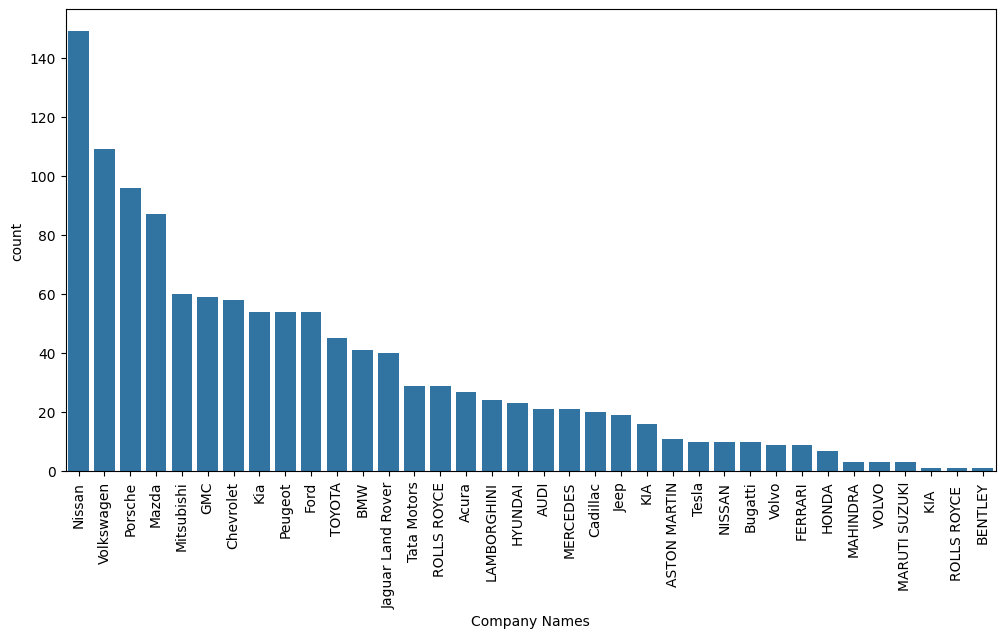

In [ ]:
Company=df['Company Names'].value_counts().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(x=Company['Company Names'],y=Company['count'])
plt.xticks(rotation=90)
plt.show()

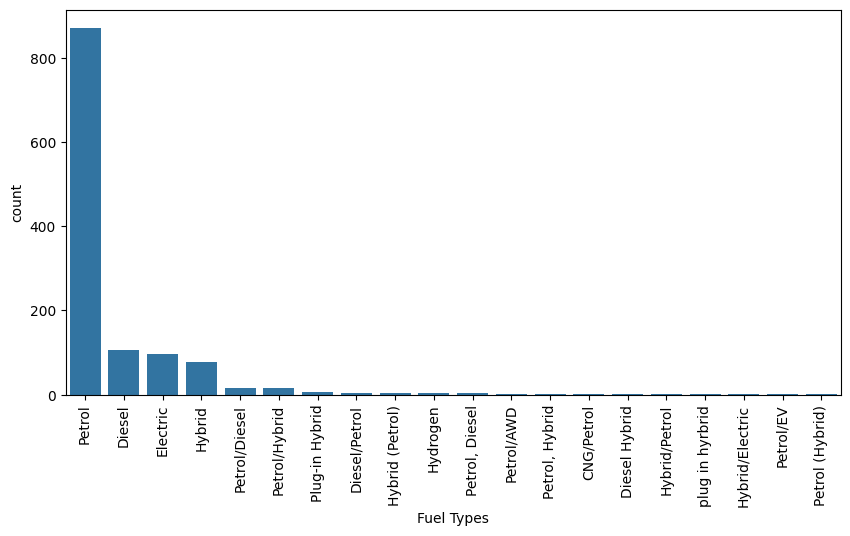

In [ ]:
fuel_type=df['Fuel Types'].value_counts().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(x=fuel_type['Fuel Types'],y=fuel_type['count'])
plt.xticks(rotation=90)
plt.show()

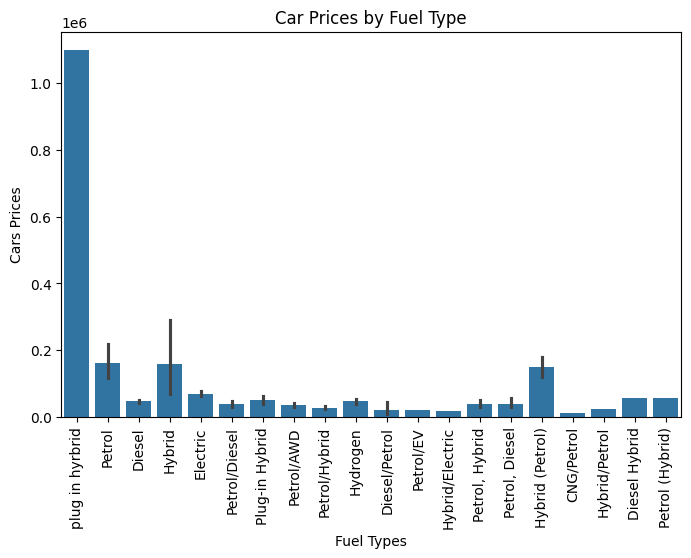

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Fuel Types', y='Cars Prices')
plt.title("Car Prices by Fuel Type")
plt.xticks(rotation=90)
plt.show()

In [ ]:
fuel_company=df.groupby(['Fuel Types','Company Names'])['Cars Prices'].mean().sort_values(ascending=False).reset_index().head(10)
fuel_company

,Fuel Types,Company Names,Cars Prices
0,Petrol,Bugatti,5.870000e+06
1,Hybrid,LAMBORGHINI,2.800000e+06
2,Hybrid,ASTON MARTIN,2.150000e+06
3,plug in hyrbrid,FERRARI,1.100000e+06
4,Petrol,LAMBORGHINI,5.566087e+05
5,Petrol,ASTON MARTIN,4.424933e+05
6,Petrol,FERRARI,4.387500e+05
7,Petrol,ROLLS ROYCE,3.924138e+05
8,Petrol,ROLLS ROYCE,3.320000e+05
9,Petrol,BENTLEY,3.110000e+05


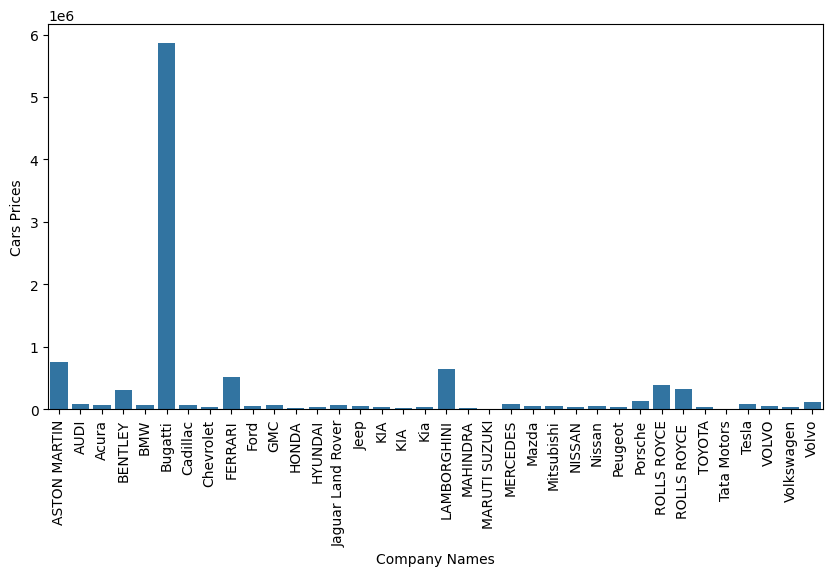

In [ ]:
company_price=df.groupby('Company Names')['Cars Prices'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(x=company_price['Company Names'],y=company_price['Cars Prices'])
plt.xticks(rotation=90)
plt.show()

In [ ]:
def extract_sum(value):
    if isinstance(value, str) and '+' in value: # Check if value is a string first
        return value.split('+')[1]
    return value
df['Seats']=df['Seats'].apply(extract_sum)

In [ ]:
df['Seats'].value_counts().reset_index()

,Seats,count
0,5.0,688
1,4.0,161
2,7.0,152
3,2.0,142
4,8.0,29
5,6.0,20
6,3.0,14
7,1.0,3
8,20.0,1
9,15.0,1


In [ ]:
df['Price per HorsePower']=df['Cars Prices']/df['HorsePower']
df['Price per Performance']=df['Cars Prices']/df['Performance(0 - 100 )KM/H']

In [ ]:
top_performance = df.sort_values(by='Performance(0 - 100 )KM/H', ascending=True).head(10)
print("Top Performing Cars:\n", top_performance[['Company Names', 'Cars Names', 'Performance(0 - 100 )KM/H','Cars Prices']])


Top Performing Cars:
     Company Names          Cars Names  Performance(0 - 100 )KM/H  Cars Prices
668         Tesla          Roadster 2                        1.9     200000.0
660         Tesla       Model S Plaid                        2.1     108490.0
888       Bugatti              Bolide                        2.2    4500000.0
881       Bugatti    Chiron Pur Sport                        2.3    3300000.0
882       Bugatti  Chiron Super Sport                        2.4    3500000.0
883       Bugatti        Chiron Sport                        2.4    3300000.0
885       Bugatti                Divo                        2.4    5800000.0
886       Bugatti          Centodieci                        2.4    9000000.0
889       Bugatti             Mistral                        2.4    5000000.0
0         FERRARI       SF90 STRADALE                        2.5    1100000.0


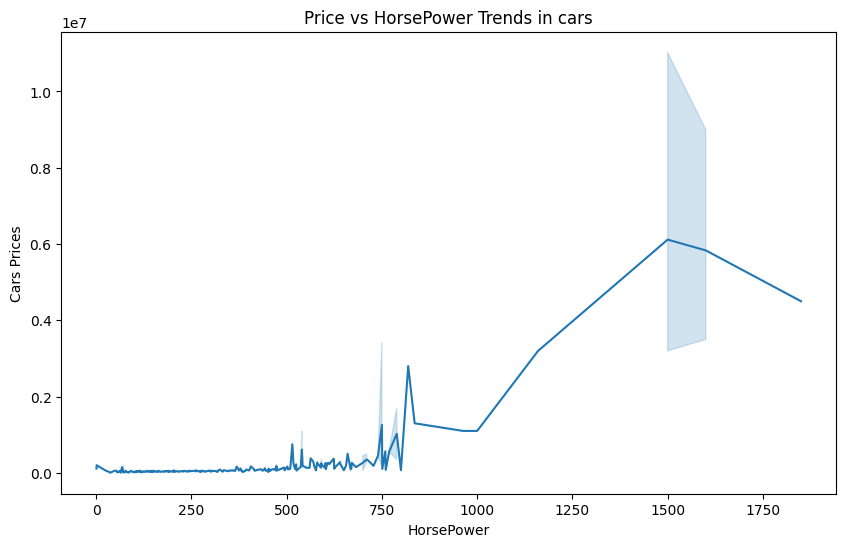

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='HorsePower', y='Cars Prices')
plt.title("Price vs HorsePower Trends in cars")
plt.show()

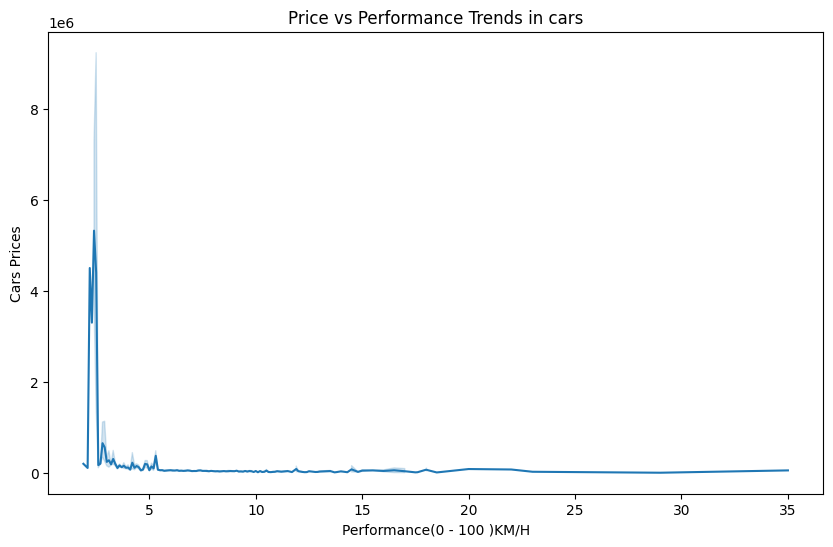

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Performance(0 - 100 )KM/H', y='Cars Prices')
plt.title("Price vs Performance Trends in cars")
plt.show()

In [ ]:
luxuries_cars = df.sort_values(by='Cars Prices', ascending=False).head(10)
print("Top expensive Cars:\n", luxuries_cars[['Company Names', 'Cars Names', 'Performance(0 - 100 )KM/H','Cars Prices','Fuel Types','CC/Battery Capacity']])


Top expensive Cars:
     Company Names          Cars Names  Performance(0 - 100 )KM/H  Cars Prices  \
887       Bugatti    La Voiture Noire                        2.5   18000000.0   
886       Bugatti          Centodieci                        2.4    9000000.0   
885       Bugatti                Divo                        2.4    5800000.0   
889       Bugatti             Mistral                        2.4    5000000.0   
8     LAMBORGHINI     VENENO ROADSTER                        2.9    4500000.0   
888       Bugatti              Bolide                        2.2    4500000.0   
882       Bugatti  Chiron Super Sport                        2.4    3500000.0   
881       Bugatti    Chiron Pur Sport                        2.3    3300000.0   
883       Bugatti        Chiron Sport                        2.4    3300000.0   
884       Bugatti        Chiron Noire                        2.5    3300000.0   

    Fuel Types  CC/Battery Capacity  
887     Petrol             7993.000  
886     Pet

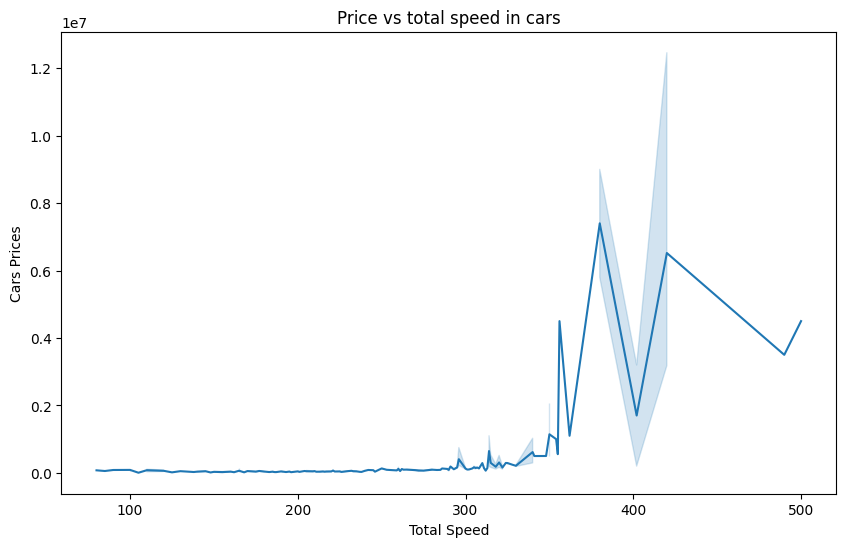

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Total Speed', y='Cars Prices')
plt.title("Price vs total speed in cars")
plt.show()

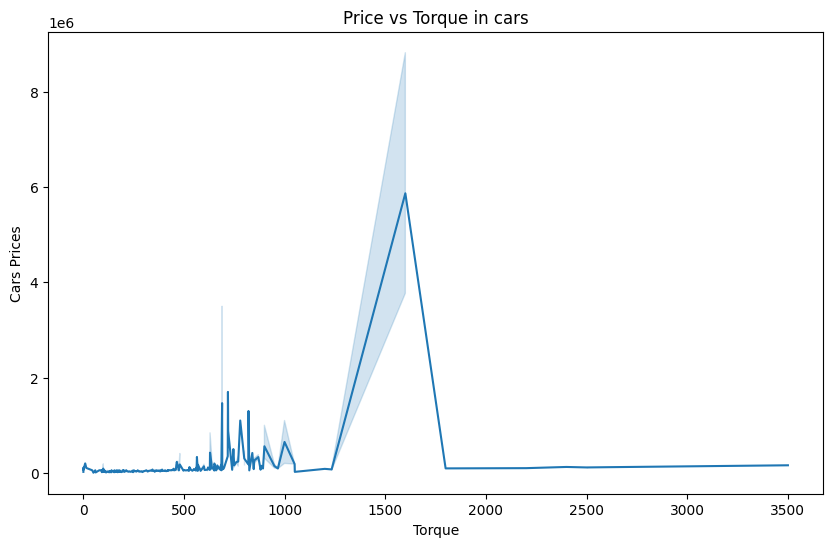

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Torque', y='Cars Prices')
plt.title("Price vs Torque in cars")
plt.show()

In [ ]:
df['Engines'].value_counts()

,count
Engines,
I4,64
V12,51
V6,39
Inline-4,38
V8,34
...,...
3.0L Twin-Turbo V6 Gasoline,1
4.2L Naturally Aspirated Flat-6,1
1.2L Revotron Petrol / 1.5L Diesel,1


In [ ]:
from sklearn.preprocessing import LabelEncoder
df['Engines']=LabelEncoder().fit_transform(df['Engines'])
dff=df.copy()
dff['Company Names']=LabelEncoder().fit_transform(dff['Company Names'])
dff['Fuel Types']=LabelEncoder().fit_transform(dff['Fuel Types'])

<Axes: >

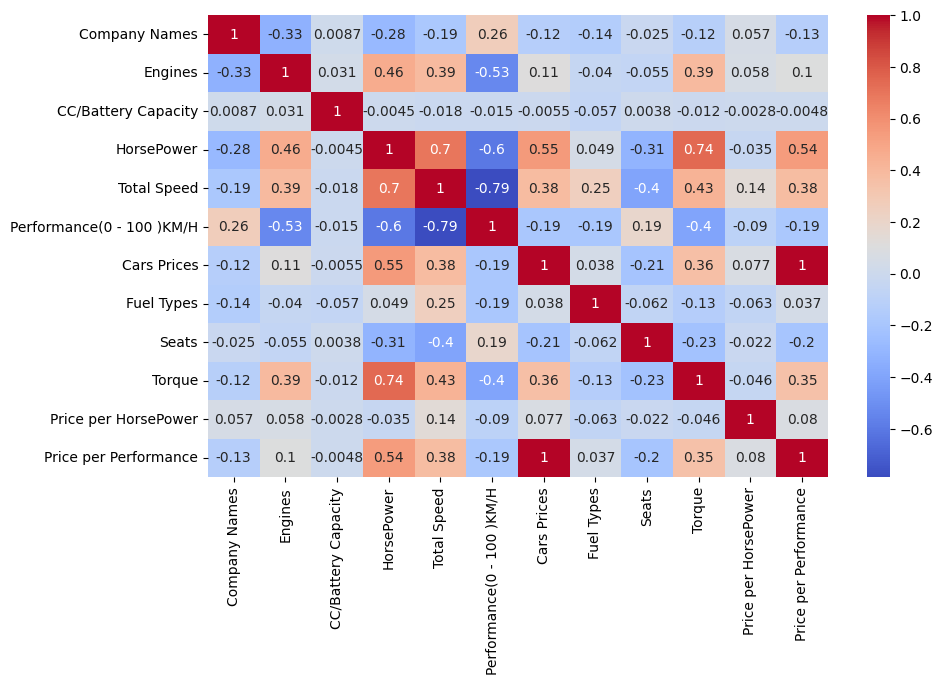

In [ ]:
corr=dff.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [ ]:
corr['Cars Prices'].sort_values(ascending=False)

,Cars Prices
Cars Prices,1.000000
Price per Performance,0.997711
HorsePower,0.551733
Total Speed,0.381285
Torque,0.358610
Engines,0.112664
Price per HorsePower,0.077415
Fuel Types,0.038155
CC/Battery Capacity,-0.005488
Company Names,-0.124329


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
X = dff[['HorsePower', 'Total Speed', 'Torque','Performance(0 - 100 )KM/H','Seats']]
y = dff['Cars Prices']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
rmse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(rmse)
print(f"RMSE: {rmse}")

RMSE: 418759.85984199547


In [ ]:
from sklearn.linear_model import Ridge
model = Ridge(alpha=100)  # Adjust alpha for regularization strength
model.fit(X_train, y_train)

# Predict and evaluate
predictions = model.predict(X_test)
rmse1 = mean_squared_error(y_test, predictions)
rmse1 = np.sqrt(rmse1)
print(f"RMSE: {rmse1}")

RMSE: 320437.3673551059


In [ ]:
from xgboost import XGBRegressor
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
predictions = model.predict(X_test)
rmse2 = mean_squared_error(y_test, predictions)
rmse2 = np.sqrt(rmse2)
print(f"RMSE: {rmse2}")

RMSE: 488834.77076412225


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Optimized RMSE: {rmse}")


Optimized RMSE: 211944.0041655183


In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, predictions)
print(f"MAE: {mae}")

MAE: 47541.09013884749


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, predictions)
print(f"R² Score: {r2}")

R² Score: 0.703825107132692


In [ ]:
print(f"Target Range: Min = {y_test.min()}, Max = {y_test.max()}")


Target Range: Min = 6200.0, Max = 5000000.0


In [ ]:
target_range = y_test.max() - y_test.min()
proportional_error = (rmse / target_range) * 100
print(f"Proportional RMSE: {proportional_error:.2f}%")

Proportional RMSE: 4.24%


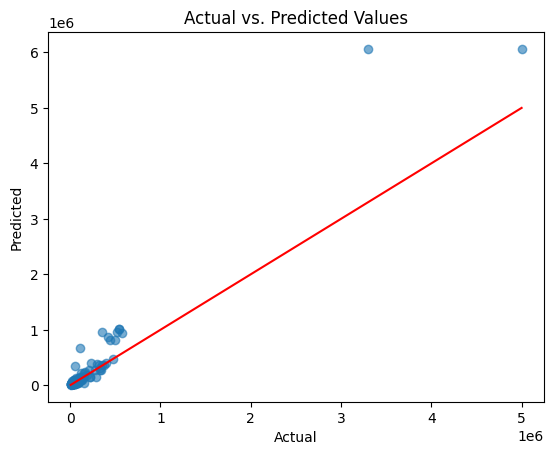

In [ ]:
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs. Predicted Values")
plt.show()


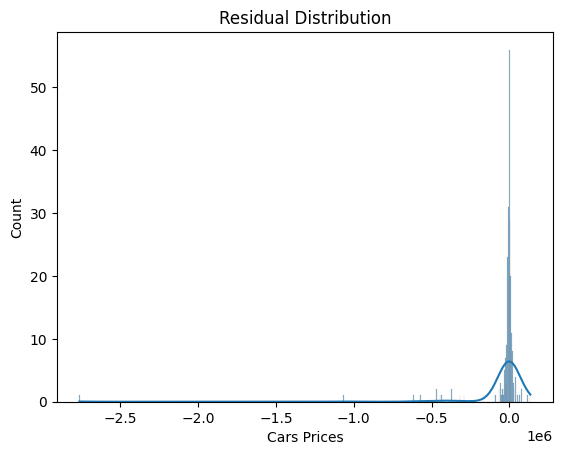

In [ ]:
residuals = y_test - predictions
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Optimized RMSE: {rmse}")

Optimized RMSE: 217869.07628831596
